In [1]:
import os
os.chdir("../")

import yaml
from collections import defaultdict

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

import torch
import numpy as np
from utils.data_utils import normalize_patient_info, sex_transform
from module.IBExtractor import IBExtractor


In [2]:
# Load dataset
dataset = torch.load("data/Mimic_vae_multi_nomic_test.pt")
# dataset = torch.load("data/Mimic_vae_nomic_test.pt")
# grouping
grouped_dataset = defaultdict(list)
for entry in dataset:
    id = entry['label']['subject_id']
    grouped_dataset[id].append(entry)


In [3]:
patient_list = []
for key, value in grouped_dataset.items():
    if len(value) > 85:
        patient_list.append(key)
print(len(patient_list))
if len(patient_list) < 20:
    print(patient_list)

10
[10030753, 10098993, 10108435, 10123949, 10207476, 10213338, 10439110, 10577647, 10578325, 10580201]


In [4]:
device = "cuda:0"
config_root = "config/IBEConfig.yaml"
checkpoint_path = "checkpoints/ibe_model.pth"
with open(config_root, 'r') as f:
    config = yaml.safe_load(f) 
ibe_model = IBExtractor(embed_dim=config['embed_dim'], num_heads=config['num_heads'], ff_hidden_size=config['ff_hidden_size'], num_layers=config['num_layers'], text_embed_dim=config['text_embed_dim'], patient_info_size=config['patient_info_size'])
ibe_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
ibe_model.to(device)
ibe_model.eval()
print("done")

done


## Validation part

In [5]:
X = []
Y = []
label = 0
with torch.no_grad():
    for patient in patient_list:
        ecg_list = grouped_dataset[patient]
        for ecg in ecg_list:
            ecg_latent = ecg['data'].unsqueeze(0).transpose(2, 1).to(device)
            text_embed = ecg['label']['text_embed'].unsqueeze(0).to(device)
            text_embed_mask = torch.ones(text_embed.shape[1], device=device).unsqueeze(0)

            pat_info_vector = torch.tensor([normalize_patient_info('hr', ecg['label']['hr']), 
                                            normalize_patient_info('age', ecg['label']['age']),
                                            normalize_patient_info('sex', sex_transform(ecg['label']['sex']))], device=device, dtype=torch.float32)
            pat_info_vector = pat_info_vector.unsqueeze(0)
            # text_embed = None

            ib_vector = ibe_model.extract_features(ecg_latent, text_embed, text_embed_mask, pat_info_vector, reduce=True)
            ib_vector = ecg_latent.reshape(1, -1)

            X.append(ib_vector.cpu())
            Y.append(label)
        label += 1

X = torch.concat(X).numpy()
Y = np.array(Y)

In [6]:
X.shape, Y.shape

((1135, 512), (1135,))

In [128]:
def compute_ib_similarity(X, Y):
    scores = []
    size = X.shape[0]
    X = torch.from_numpy(X)
    X /= torch.norm(X, dim=1, keepdim=True)
    for i in range(size):
        p_score = 0
        n_score = 0
        label = Y[i]
        for j in range(size):
            cos_sim = X[i] @ X[j]
            if label == Y[j]:
                p_score += cos_sim
            else:
                n_score += cos_sim
        p_score /= sum(Y == label) 
        n_score /= sum(Y != label)
        score = p_score - n_score
        scores.append(score)
    print(torch.mean(torch.tensor(scores)))

compute_ib_similarity(X, Y)

tensor(0.3520)


In [8]:
# Initialize t-SNE
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)

# Fit and transform
X_embedded = tsne.fit_transform(X)

# Get unique classes from Y
classes = np.unique(Y)
n_classes = len(classes)

In [127]:
from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(X_embedded, Y)
silhouette_avg

0.3196822

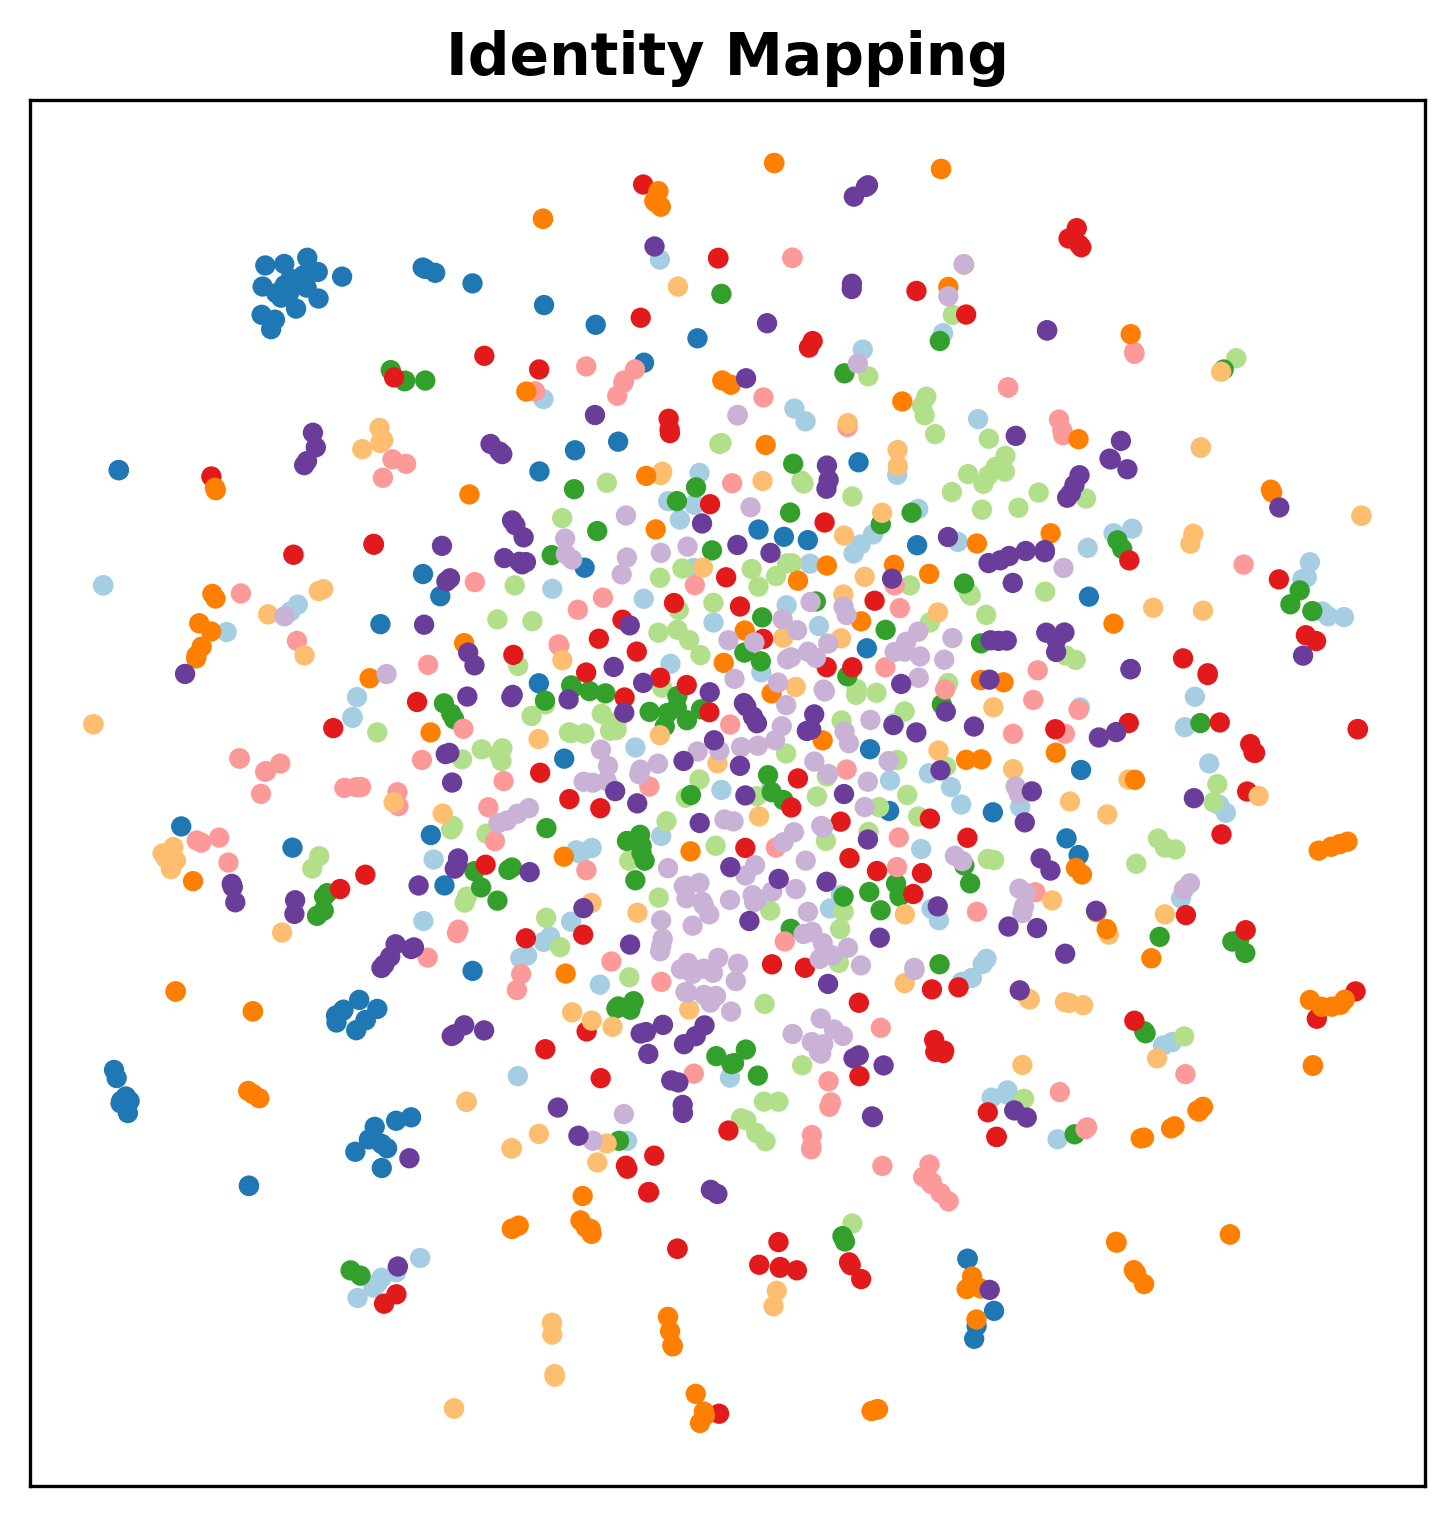

In [ ]:

from matplotlib.colors import ListedColormap, BoundaryNorm
# Create a colormap with only the needed colors
base_cmap = plt.get_cmap('Paired')
# base_cmap = plt.get_cmap('tab20')
colors = base_cmap(np.linspace(0, 1, base_cmap.N))
custom_cmap = ListedColormap(colors[:n_classes])

# Set up a normalizer to match class labels to colors
norm = BoundaryNorm(np.arange(n_classes+1), n_classes)

# Plot the result
plt.figure(figsize=(6, 6), dpi=300)
scatter = plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=Y, cmap=custom_cmap, norm=norm, s=15)
# plt.colorbar(scatter, label='Patient ID')

plt.title('Identity Mapping', fontsize=14, weight='bold')
plt.xticks([])
plt.yticks([])
# plt.title('t-SNE visualization of ECG Latent')
# plt.xlabel('t-SNE 1')
# plt.ylabel('t-SNE 2')
# plt.grid(True)
# plt.savefig("figure/tSNE/temp.pdf", bbox_inches='tight')
plt.show()

## Generation part

In [6]:
from diffusers import DDPMScheduler
from module.vae_model import VAE_Decoder
from utils.inference_utils import ddpm_generation
from utils.model_utils import build_noise_predictor

gen_config_root = "config/DiT_ECGTwin.yaml"
with open(gen_config_root, 'r') as f:
    config = yaml.safe_load(f) 
h_ = config['hyper_para']
model_type = config['meta']['model_type']
n_channels = 4

ckpt_path = './checkpoints/ECGTwin_DiT.pth'
noise_predictor = build_noise_predictor(model_type, n_channels, h_)
noise_predictor_ckpt = torch.load(ckpt_path, map_location=device)
noise_predictor.load_state_dict(noise_predictor_ckpt)
noise_predictor.to(device)
noise_predictor.eval()

diffused_model = DDPMScheduler(num_train_timesteps=h_['ddpm']['num_train_steps'], beta_start=h_['ddpm']['beta_start'], beta_end=h_['ddpm']['beta_end'])
diffused_model.set_timesteps(1000)

decoder = VAE_Decoder()
vae_path = config['dependencies']['vae_path']
vae_checkpoint = torch.load(vae_path, map_location=device)
decoder.load_state_dict(vae_checkpoint['decoder'])
decoder.to(device)
decoder.eval()

num = 10

In [7]:
new_patient_list = patient_list[7:9]
new_patient_list.append(patient_list[4])

In [8]:
X = []
Y = []
label = 0
with torch.no_grad():
    for idx, patient in enumerate(new_patient_list):
        print(f"Patient {idx}: {patient}")
        print(f"Extracting ib vector from real ECG of patient {idx}")
        ecg_list = grouped_dataset[patient]
        for ecg in ecg_list:
            ecg_latent = ecg['data'].unsqueeze(0).transpose(2, 1).to(device)
            text_embed = ecg['label']['text_embed'].unsqueeze(0).to(device)
            text_embed_mask = torch.ones(text_embed.shape[1], device=device).unsqueeze(0)

            pat_info_vector = torch.tensor([normalize_patient_info('hr', ecg['label']['hr']), 
                                            normalize_patient_info('age', ecg['label']['age']),
                                            normalize_patient_info('sex', sex_transform(ecg['label']['sex']))], device=device, dtype=torch.float32)
            pat_info_vector = pat_info_vector.unsqueeze(0)

            ib_vector = ibe_model.extract_features(ecg_latent, text_embed, text_embed_mask, pat_info_vector, reduce=True)

            X.append(ib_vector.cpu())
            Y.append(label)

        label += 1

        # perform generation based on first ecg
        print(f"Generating ECG for patient {idx}")
        for start in range(0, len(ecg_list)-1, max(2, len(ecg_list) // num)):
            gen_batch = len(ecg_list) // num
            ecg_ref = ecg_list[start]
            ecg_latent_ref = ecg_ref['data'].unsqueeze(0).transpose(2, 1).to(device)
            text_embed_ref = ecg_ref['label']['text_embed'].unsqueeze(0).to(device)
            text_embed_mask_ref = torch.ones(text_embed_ref.shape[1], device=device).unsqueeze(0)

            pat_info_vector_ref = torch.tensor([normalize_patient_info('hr', ecg_ref['label']['hr']), 
                                            normalize_patient_info('age', ecg_ref['label']['age']),
                                            normalize_patient_info('sex', sex_transform(ecg_ref['label']['sex']))], device=device, dtype=torch.float32)
            pat_info_vector_ref = pat_info_vector_ref.unsqueeze(0)
            # text_embed_ref = None
            ib_vector = ibe_model.extract_features(ecg_latent_ref, text_embed_ref, text_embed_mask_ref, pat_info_vector_ref, reduce=True)
            ib_vector = ib_vector.repeat(gen_batch, 1)

            ecg_tar = ecg_list[start+1]
            text_embed_tar = ecg_tar['label']['text_embed'].unsqueeze(0).repeat(gen_batch, 1, 1).to(device)
            pat_info_vector_tar = torch.tensor([normalize_patient_info('hr', ecg_tar['label']['hr']), 
                                            normalize_patient_info('age', ecg_tar['label']['age']),
                                            normalize_patient_info('sex', sex_transform(ecg_tar['label']['sex']))], device=device, dtype=torch.float32)
            pat_info_vector_tar = pat_info_vector_tar.unsqueeze(0).repeat(gen_batch, 1)
            latent_gen = ddpm_generation(diffused_model=diffused_model, 
                                        noise_predictor=noise_predictor, 
                                        batch_size=gen_batch, 
                                        device=device, 
                                        text_embed=text_embed_tar, 
                                        text_embed_mask=None, 
                                        pat_info=pat_info_vector_tar, 
                                        base_vector=ib_vector)

            latent_gen = latent_gen.transpose(2, 1)
            gen_ib_vector = ibe_model.extract_features(latent_gen, text_embed_tar, None, pat_info_vector_tar, reduce=True)
            gen_ib_list = [ib.cpu() for ib in torch.split(gen_ib_vector, 1)]
            X.extend(gen_ib_list)
            Y.extend([label] * len(gen_ib_list))

        label += 1
        if idx == 2:
            break

X = torch.concat(X).numpy()
Y = np.array(Y)


Patient 0: 10577647
Extracting ib vector from real ECG of patient 0
Generating ECG for patient 0


100%|██████████| 1000/1000 [00:06<00:00, 152.85it/s]


Patient 1: 10578325
Extracting ib vector from real ECG of patient 1
Generating ECG for patient 1


100%|██████████| 1000/1000 [00:06<00:00, 144.72it/s]


Patient 2: 10207476
Extracting ib vector from real ECG of patient 2
Generating ECG for patient 2


100%|██████████| 1000/1000 [00:06<00:00, 150.25it/s]


In [9]:
X.shape, Y.shape

((714, 256), (714,))

In [17]:
def compute_ib_similarity(X, Y):
    scores = []
    size = X.shape[0]
    X = torch.from_numpy(X)
    X /= torch.norm(X, dim=1, keepdim=True)
    Y = Y // 2
    for i in range(size):
        p_score = 0
        n_score = 0
        label = Y[i]
        for j in range(size):
            cos_sim = X[i] @ X[j]
            if label == Y[j]:
                p_score += cos_sim
            else:
                n_score += cos_sim
        p_score /= sum(Y == label) 
        n_score /= sum(Y != label)
        score = p_score - n_score
        scores.append(score)
    print(torch.mean(torch.tensor(scores)))

compute_ib_similarity(X, Y)

tensor(0.1644)


In [11]:
# Initialize t-SNE
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)

# Fit and transform
X_embedded = tsne.fit_transform(X)

# Get unique classes from Y
classes = np.unique(Y)
n_classes = len(classes)

In [43]:
from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(X_embedded, Y // 2)
silhouette_avg

0.7428305

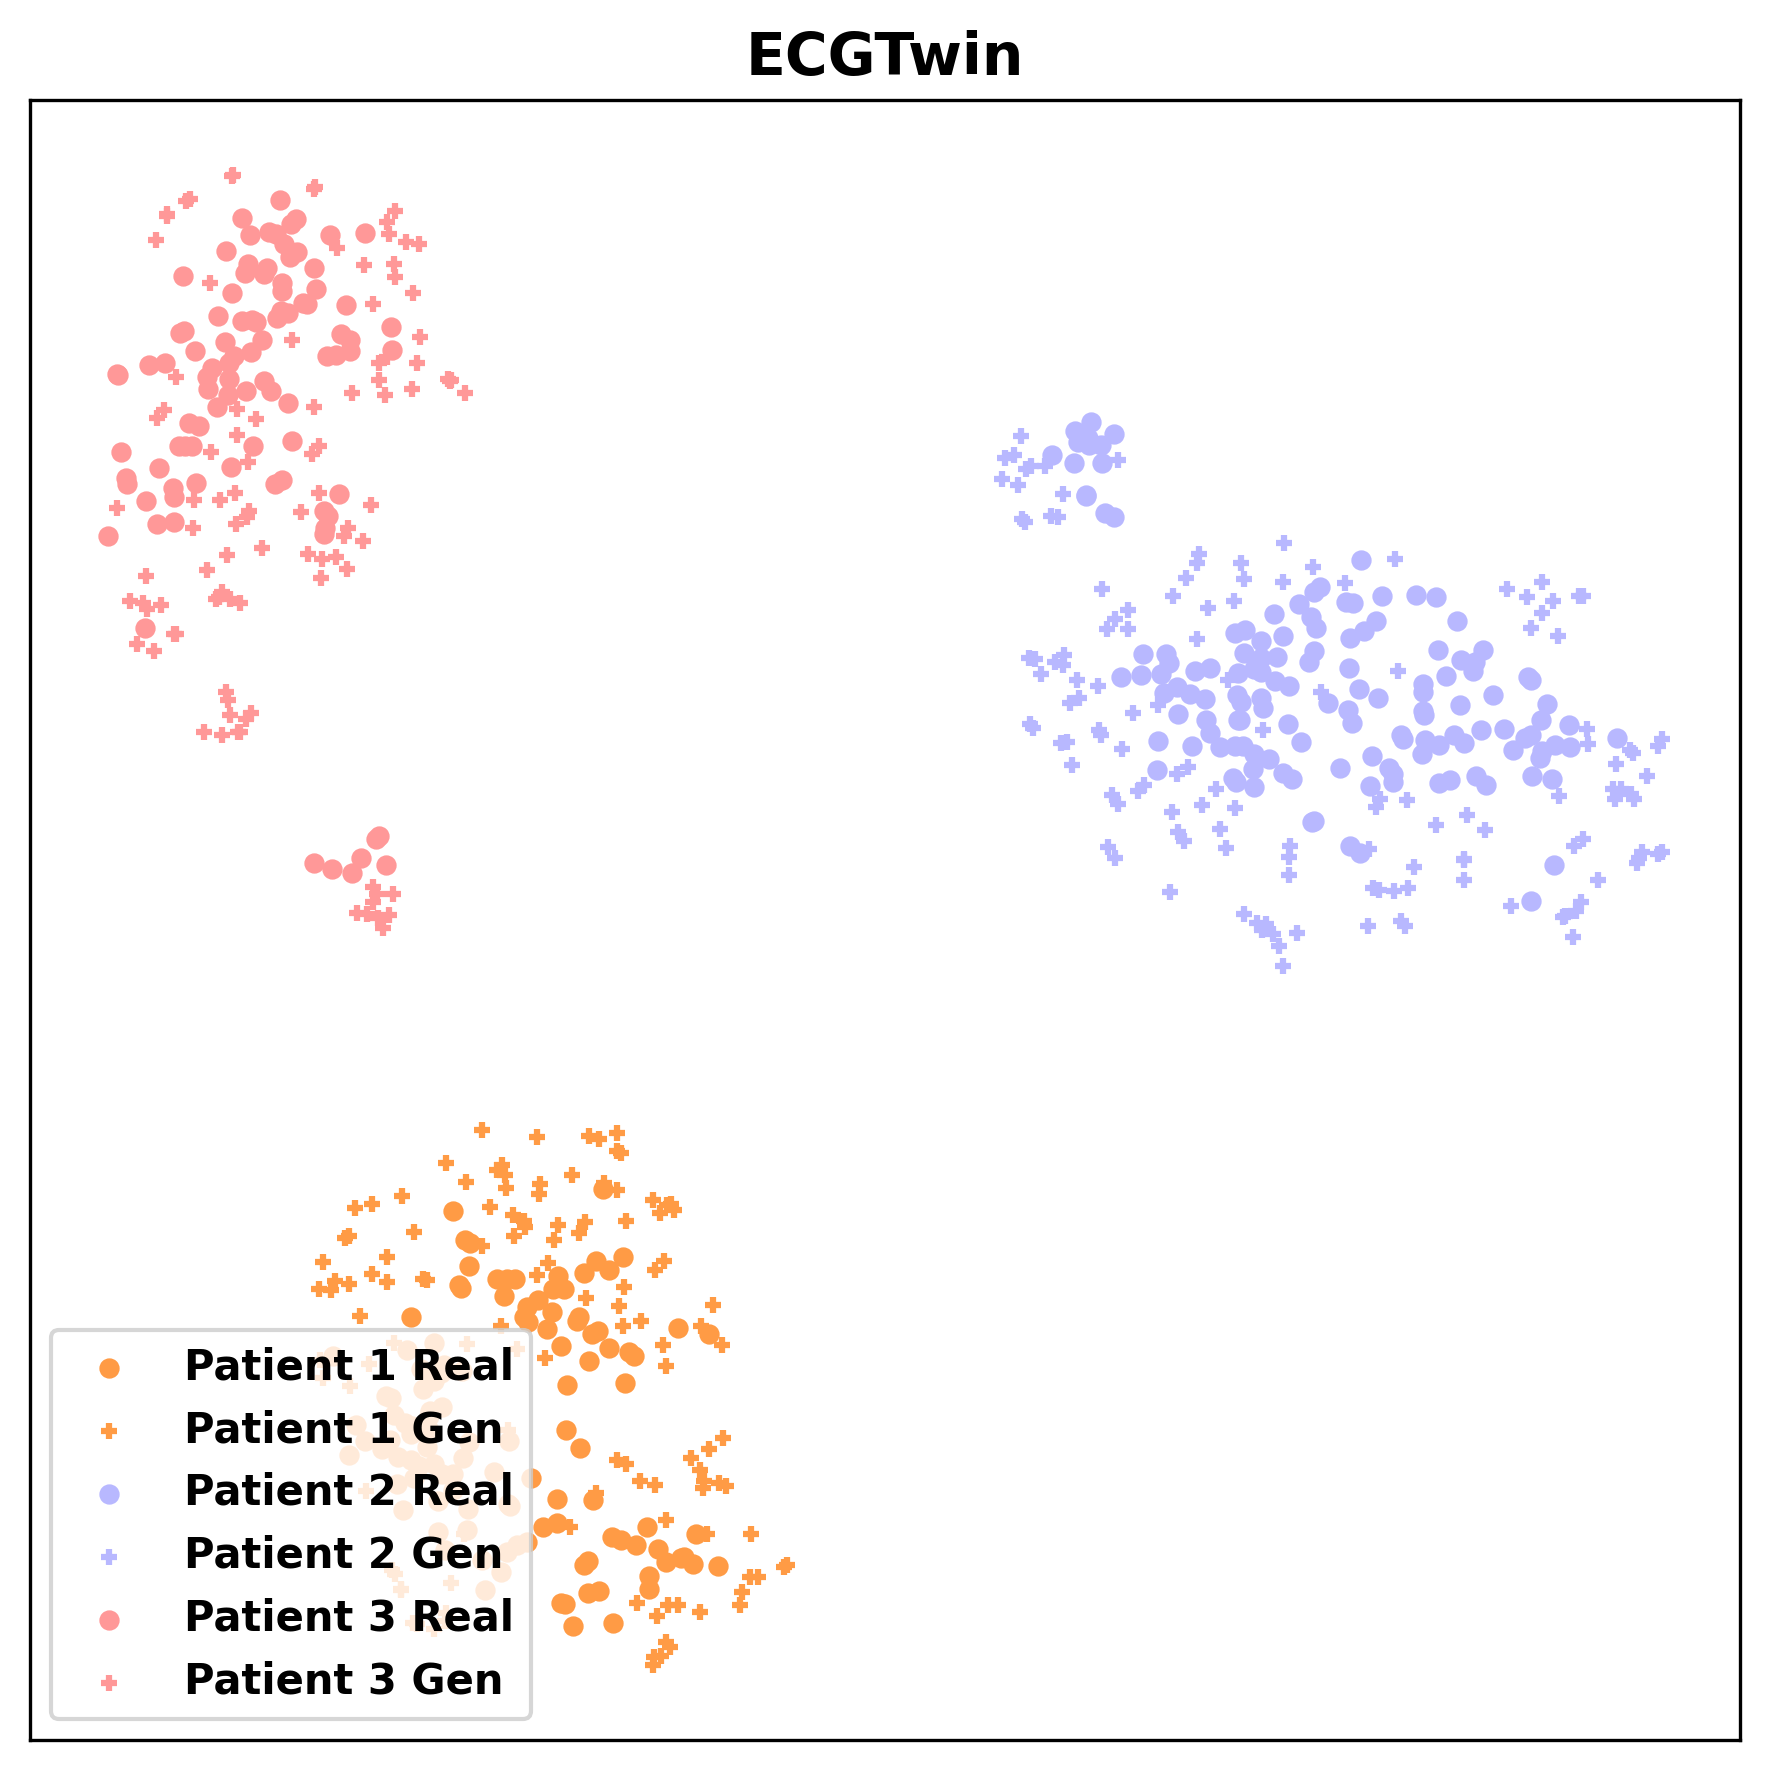

In [12]:
colors = ["#ff9b45", "#b8b8ff", "#ff9898"]
# Plot the result
plt.figure(figsize=(6, 6), dpi=300)
for p_id, idx in enumerate(range(0, n_classes, 2)):
    scatter = plt.scatter(X_embedded[Y == idx, 0], X_embedded[Y == idx, 1], label=f"Patient {idx // 2 + 1} Real", s=15, c=colors[p_id])
    scatter = plt.scatter(X_embedded[Y == idx+1, 0], X_embedded[Y == idx+1, 1], label=f"Patient {idx // 2 + 1} Gen", s=15, c=colors[p_id], marker='+')

# plt.legend()
plt.legend(frameon=True, prop={"weight": "bold", "size": 10}, loc="lower left")
plt.title('ECGTwin', fontsize=14, weight='bold')
plt.xticks([])
plt.yticks([])
# plt.xlabel('t-SNE 1')
# plt.ylabel('t-SNE 2')
# plt.grid(True)
plt.tight_layout()
# plt.savefig('figure/tSNE_gen/temp.pdf')
plt.show()